# VisionPlate YOLOv8s Kaggle Training Notebook

Use this notebook to train the number plate detector on Kaggle Notebooks, save graphs for the report, and resume training if interrupted.

## 1. Install Requirements
Run once. Restart the kernel if packages were newly installed.

In [1]:
!pip install ultralytics roboflow opencv-python matplotlib pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 92.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.6 MB/s eta 0:00:00


## 2. Check GPU

In [ ]:
# !pip uninstall torch torchvision torchaudio -y

In [ ]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

## 3. Download Dataset From Roboflow
Replace the values with your Roboflow dataset snippet. Choose YOLOv8 format.

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="AJ4uKoH91ufHWzsNIvoG")
project = rf.workspace("abduls-workspace-qwhgu").project("indian-license-plate-merged")
version = project.version(2)
dataset = version.download("yolov8")
                
DATA_YAML = f'{dataset.location}/data.yaml'
print(DATA_YAML)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indian-License-Plate-Merged-2 in yolov8:: 100%|██████████| 19129/19129 [00:02<00:00, 8810.08it/s] 


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
/kaggle/working/Indian-License-Plate-Merged-2/data.yaml


## 4. Train YOLOv8s
Start with `batch=4` on RTX 3050. If VRAM allows, increase to `batch=8`.

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
results = model.train(
    data=DATA_YAML,
    epochs=80,
    imgsz=640,
    batch=4,
    patience=15,
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    degrees=8,
    translate=0.08,
    scale=0.4,
    shear=2,
    perspective=0.0005,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.08,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    project='/kaggle/working/runs',
    name='yolov8s_indian_plate'
)

Ultralytics 8.4.142 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Indian-License-Plate-Merged-2/data.yaml, degrees=8, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.08, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_indian_plate, n

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


       2/80      1.27G      1.384      1.154      1.438          6        640: 100% ━━━━━━━━━━━━ 2172/2172 13.5it/s 2:410.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 15.0it/s 4.8s0.1s
                   all        570        597        0.8      0.841      0.873      0.539

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/80      1.27G      1.346      1.107      1.413          5        640: 100% ━━━━━━━━━━━━ 2172/2172 13.6it/s 2:390.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 14.9it/s 4.8s0.1s
                   all        570        597      0.899      0.881      0.939      0.514

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/80      1.27G      1.304      1.096       1.39          3        640: 100% ━━━━━━━━━━━━ 2172/2172 13.6it/s 2:390.1ss
                 Class

## 5. Resume Training If Interrupted
Run this cell only if training stopped before completion.

In [ ]:
from ultralytics import YOLO

last_weights = '/kaggle/working/runs/yolov8s_indian_plate/weights/last.pt'
model = YOLO(last_weights)
model.train(resume=True)

## 6. Validate Best Model

In [4]:
from ultralytics import YOLO

best_model = YOLO('/kaggle/working/runs/yolov8s_indian_plate/weights/best.pt')
metrics = best_model.val(data=DATA_YAML, imgsz=640)
print('mAP@0.5:', metrics.box.map50)
print('mAP@0.5:0.95:', metrics.box.map)

Ultralytics 8.4.142 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1023.4±351.2 MB/s, size: 42.6 KB)
val: Scanning /kaggle/working/Indian-License-Plate-Merged-2/valid/labels.cache... 570 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 570/570 265.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 4.2it/s 8.7s0.2s
                   all        570        597       0.98       0.95       0.99      0.777
Speed: 1.3ms preprocess, 10.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@0.5: 0.9904416356144918
mAP@0.5:0.95: 0.7771576269133211


## 7. Run Sample Predictions
These generated images are useful as screenshots for your report.

In [5]:
best_model.predict(
    source=f'{dataset.location}/test/images',
    imgsz=640,
    conf=0.25,
    save=True,
    project='/kaggle/working/runs',
    name='sample_predictions'
)


image 1/305 /kaggle/working/Indian-License-Plate-Merged-2/test/images/0c9ebe94-827d-4c74-9950-6816e70d1bab___IMG_8883-jpg_jpeg_jpg.rf.b762e7f66207f86cd718eed279c2798d.jpg: 640x640 1 license_plate, 16.1ms
image 2/305 /kaggle/working/Indian-License-Plate-Merged-2/test/images/206c95ff-83b8-4273-b105-6637bf9a3038___numerix-number-plates-thodupuzha-idukki-number-plate-dealers-1lhwiga-jpg_jpeg_jpg.rf.09a296bde75d3efa7d54c94d4858f642.jpg: 640x640 1 license_plate, 16.2ms
image 3/305 /kaggle/working/Indian-License-Plate-Merged-2/test/images/2c9306ab-3454-4ca0-89fd-db3f51dabcef___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-front-three-quarters-on-plain-ground_jpg.rf.7e70abab9490f8b02ceb63b8d683c96d.jpg: 640x640 1 license_plate, 16.2ms
image 4/305 /kaggle/working/Indian-License-Plate-Merged-2/test/images/49bdf0d9-4e64-41eb-9c19-eabdc4afb051___Maruti-Suzuki-Ciaz-Photos-30-JPG_jpeg_jpg.rf.aaed7877f0e9bc5147032f834b3a4242.jpg: 640x640 1 license_plate, 16.1ms
image 5/305 /kaggle/working/Indi

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'license_plate'}
 obb: None
 orig_img: array([[[208, 171, 137],
         [208, 171, 137],
         [208, 171, 137],
         ...,
         [213, 178, 138],
         [213, 178, 138],
         [213, 178, 138]],
 
        [[208, 171, 137],
         [208, 171, 137],
         [209, 172, 138],
         ...,
         [213, 178, 138],
         [213, 178, 138],
         [213, 178, 138]],
 
        [[208, 171, 137],
         [209, 172, 138],
         [209, 172, 138],
         ...,
         [213, 178, 138],
         [213, 178, 138],
         [213, 178, 138]],
 
        ...,
 
        [[ 71,  84,  92],
         [ 62,  75,  83],
         [ 57,  70,  78],
         ...,
         [ 73,  99, 113],
         [ 71,  97, 111],
         [ 70,  96, 110]],
 
        [[ 61,  74,  82],
         [ 54,  67,  75],
         [ 53,  66,  74],
         ...

## 8. Display Training Graphs

results.png


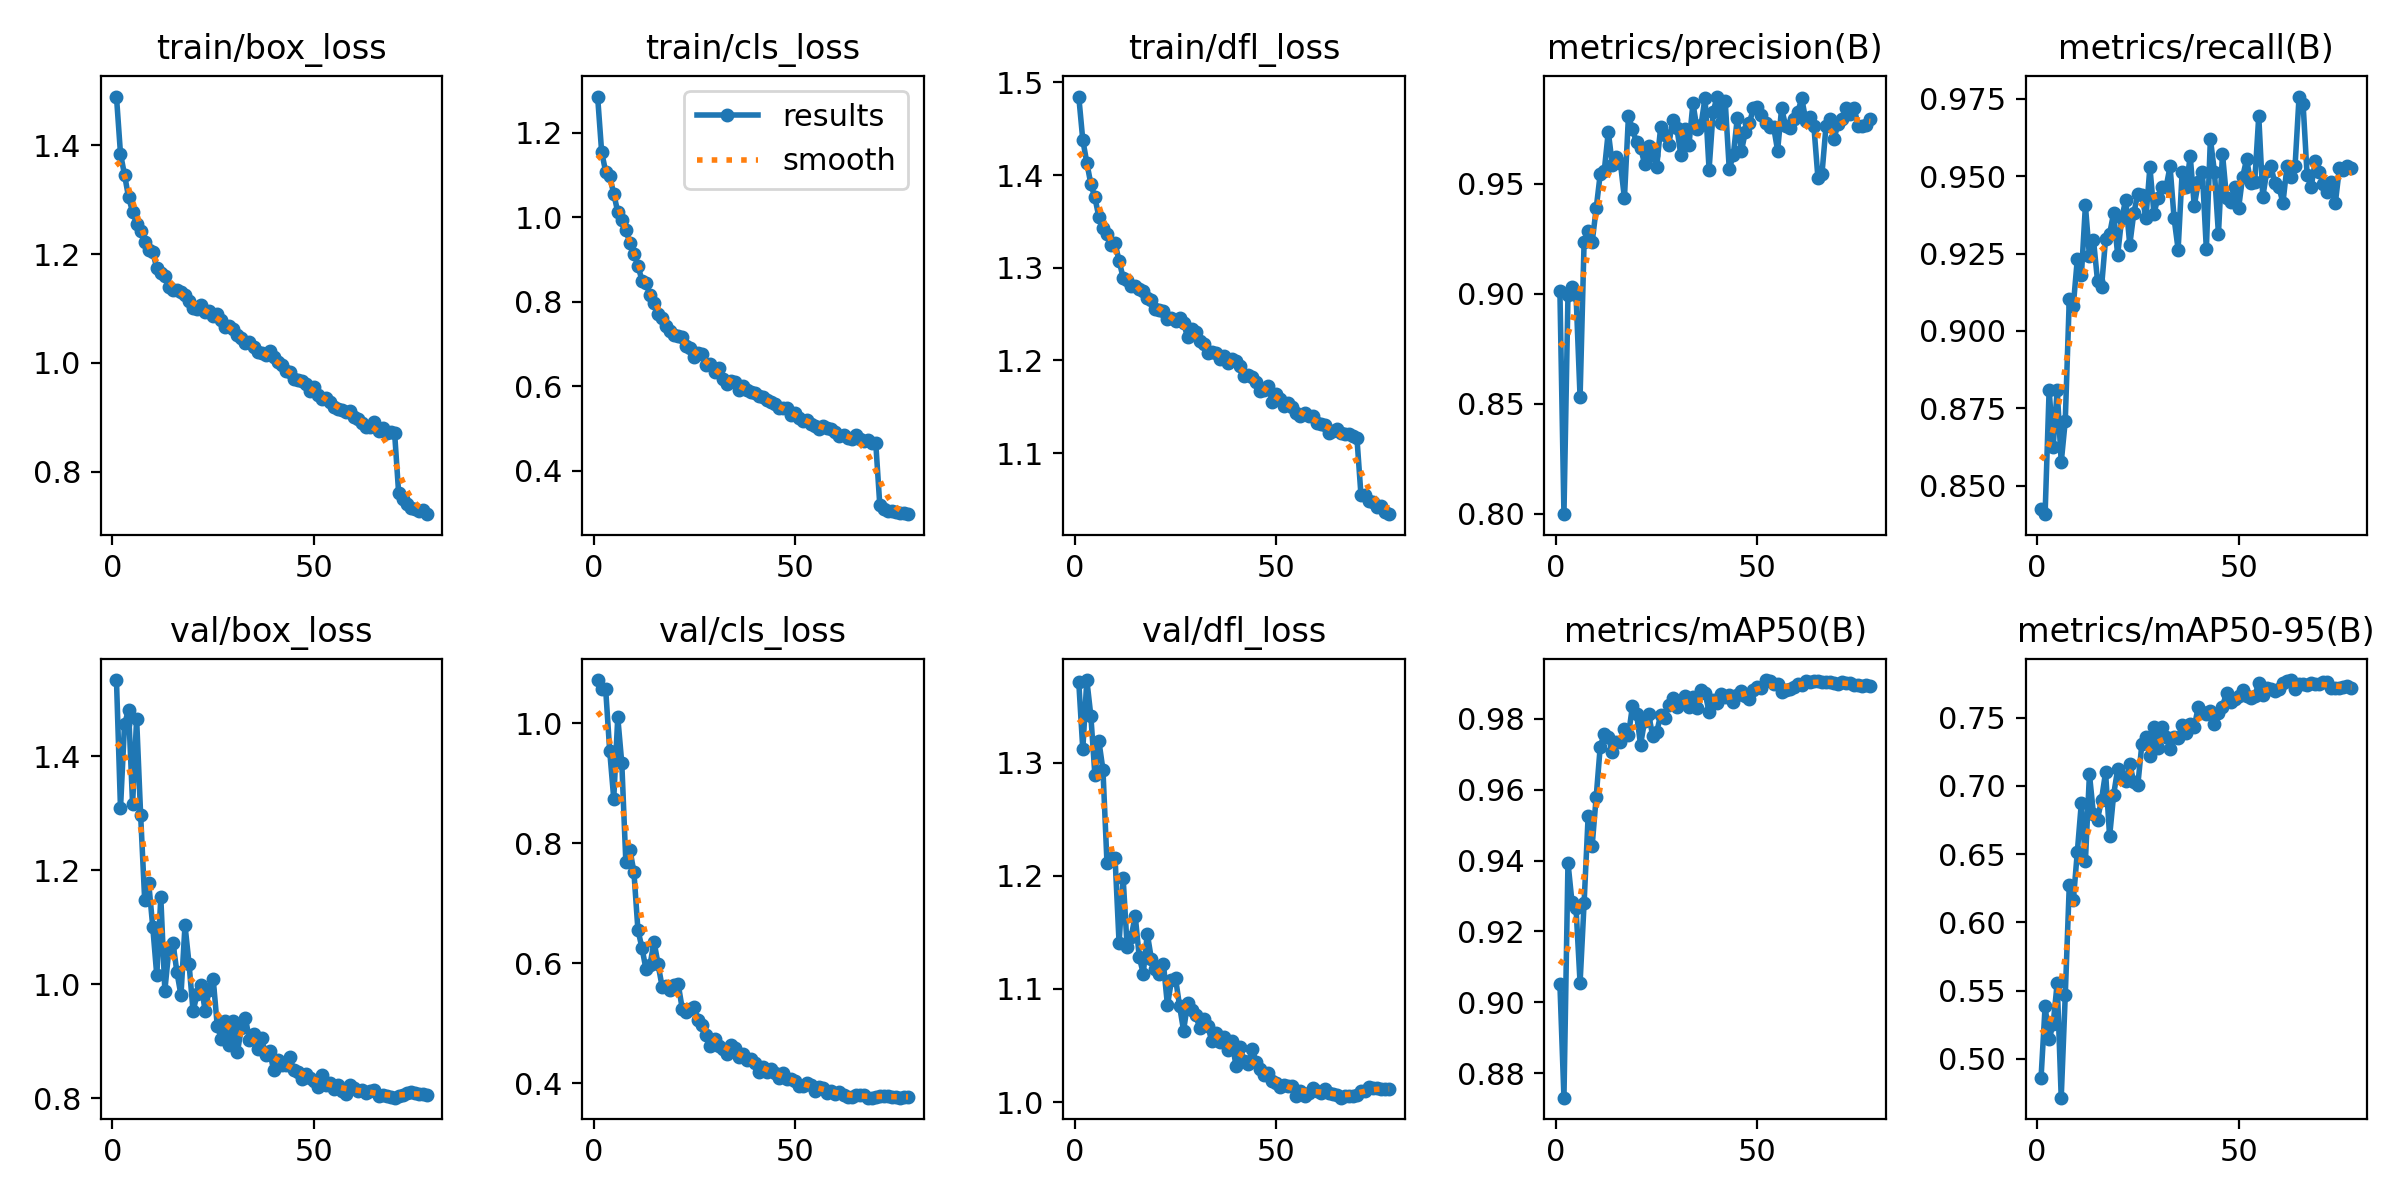

confusion_matrix.png


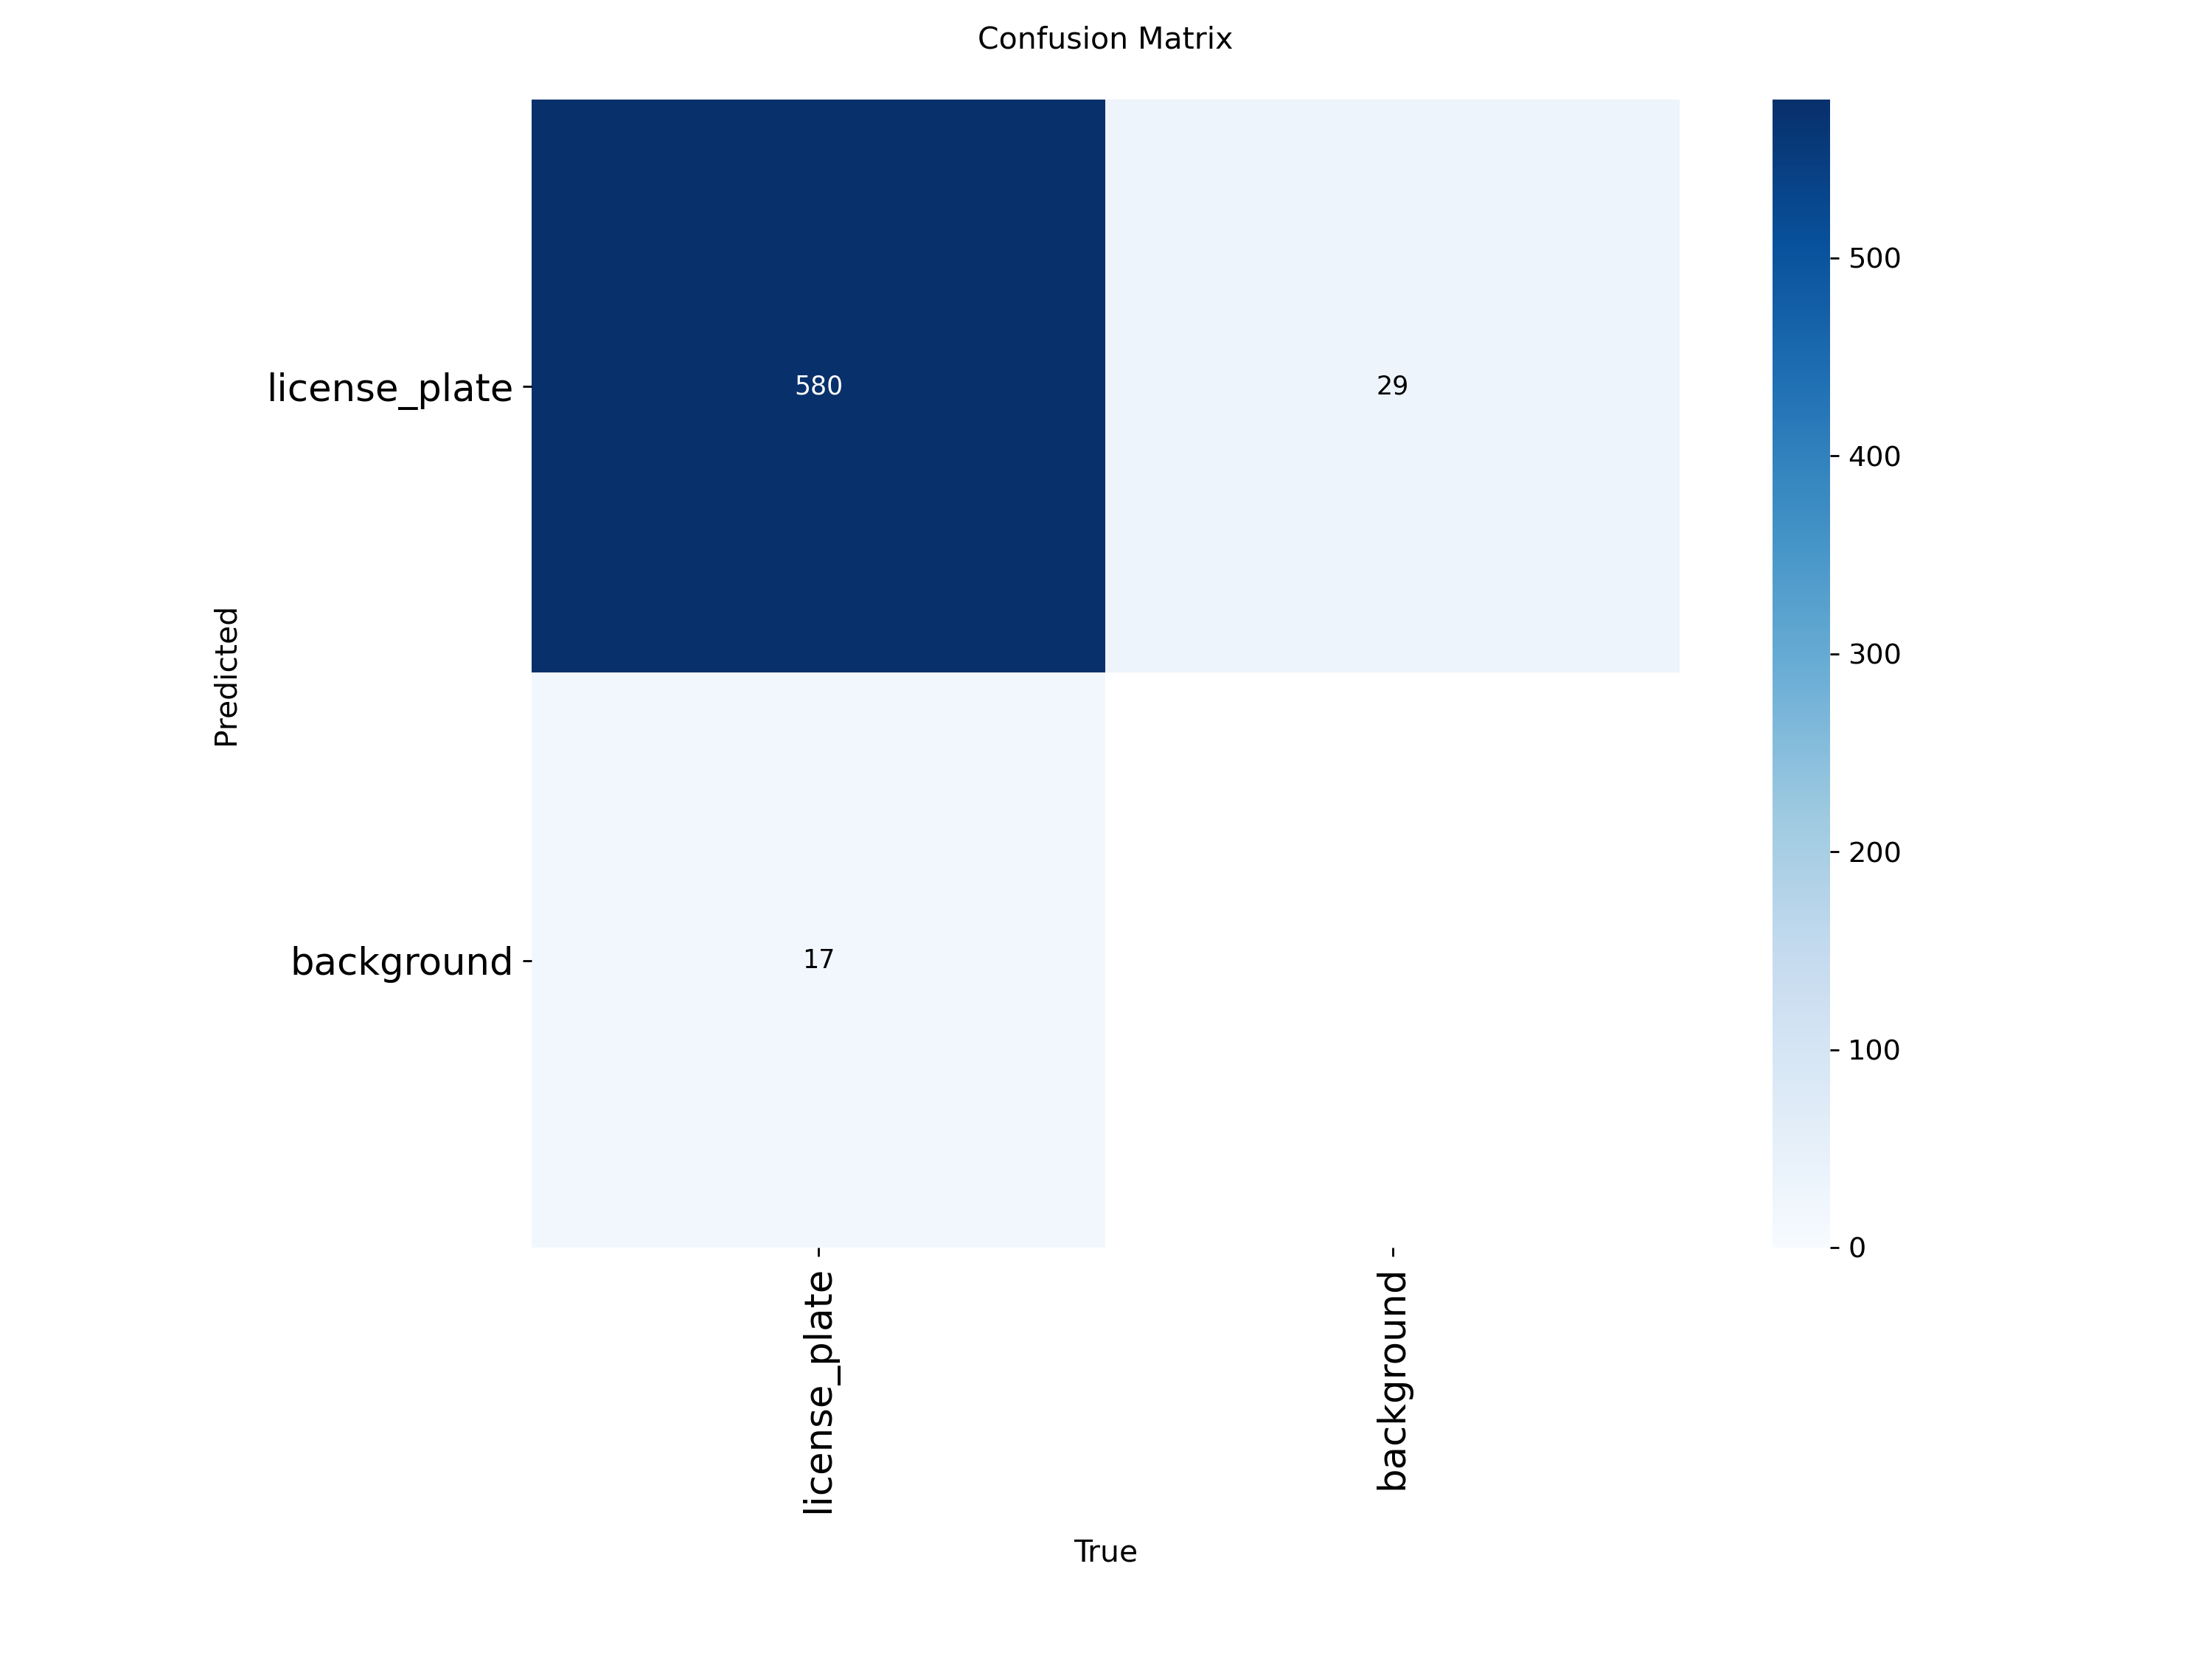

In [6]:
from IPython.display import Image, display
from pathlib import Path

run_dir = Path('/kaggle/working/runs/yolov8s_indian_plate')
for image_name in ['results.png', 'confusion_matrix.png', 'P_curve.png', 'R_curve.png', 'F1_curve.png', 'PR_curve.png']:
    image_path = run_dir / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))

## 9. Copy Best Model To Backend

In [7]:
from pathlib import Path
import shutil

source = Path('/kaggle/working/runs/yolov8s_indian_plate/weights/best.pt')
destination = Path('/kaggle/working/best.pt')
destination.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(source, destination)
print('Copied to:', destination.resolve())

Copied to: /kaggle/working/best.pt
